## **Superstore Sales & Profitability Analysis**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("data/superstore_cleaned_dataset.csv")

# Data preparation
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])
data["Postal Code"] = data["Postal Code"].astype(str)
data["Year"] = data["Year"].astype(str)

### **1. Overall Performance**

**Business Question:** What is the size and financial performance of the Superstore? How have sales and profitability changed over time?


In [2]:
total_sales = data["Sales"].sum()
total_profit = data["Profit"].sum()
total_orders = data["Order ID"].nunique()
total_customers = data["Customer ID"].nunique()
total_products = data["Product ID"].nunique()
units_sold = data["Quantity"].sum()

profit_margin = (total_profit / total_sales)*100
average_order_value = total_sales / total_orders
average_profit_order = total_profit / total_orders

##### Key Performance Indicators:

In [3]:
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Units Sold: {units_sold:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Average Profit per Order: ${average_profit_order:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%
Total Orders: 5,009
Total Customers: 793
Total Products: 1,862
Units Sold: 37,873
Average Order Value: $458.61
Average Profit per Order: $57.18


##### Sales trend chart

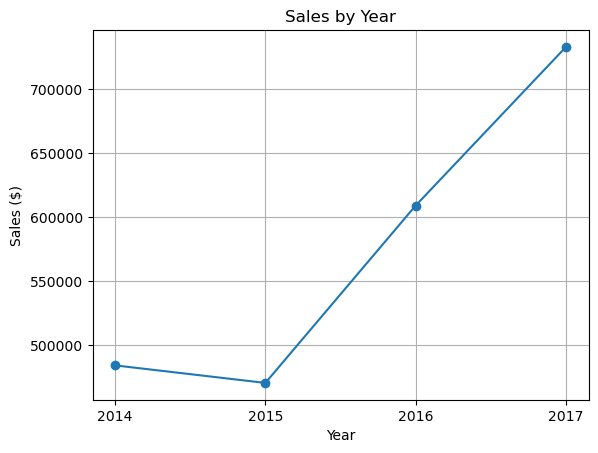

In [4]:
year_performance = (
    data.groupby("Year")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

plt.plot(
    year_performance["Year"],
    year_performance["Sales"],
    marker = "o"
)

plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.show()


##### Profit Trend Chart

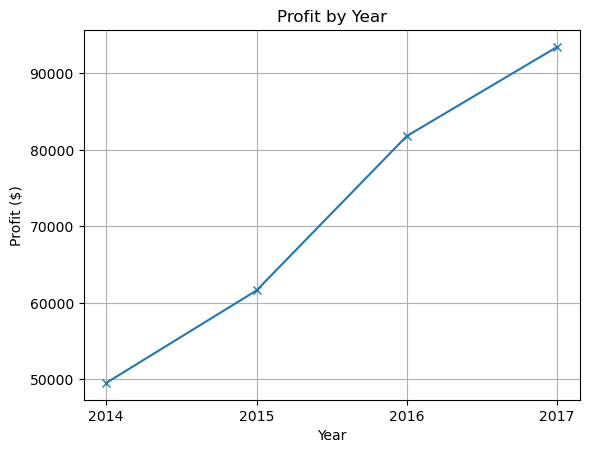

In [5]:
plt.plot(
    year_performance["Year"],
    year_performance["Profit"],
    marker = "x"
)

plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.grid(True)

plt.show()

#### **Key Findings**
- The Superstore had a total of `793` customers, `5,009` orders, and `1,862` products, generating `$2,297,200.86` in sales and `$286,397` in profit from `37,871` units sold.
- The profit margin is `12.47%`, meaning the business retained approximately `$12.47` in profit for every `$100` in sales.
- The average order value was `$458.61`, producing an average `$57.18` in profit per order.
- Sales and profit increased from 2014 to 2017, with both reaching their highest point in 2017. This shows consistent growth in sales and profitability over the period. 

### **2. Product Performance**

**Business Question:** Which products and product categories are driving sales and profitability? Where are there significant differences between sales and profit?

##### Category Performance


In [6]:
category_performance = (
    data.groupby("Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Calculate and add profit margin to each category
category_performance["Profit Margin"] = (
    category_performance["Profit"] / category_performance["Sales"] * 100
)

category_performance

,Category,Sales,Profit,Profit Margin
0,Furniture,741999.7953,18451.2728,2.486695
1,Office Supplies,719047.0320,122490.8008,17.035158
2,Technology,836154.0330,145454.9481,17.395712


##### Sub-Category Performance

In [7]:
subcategory_performance = (
    data.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Calculate and add profit margin to each sub-category
subcategory_performance["Profit Margin"] = (
    subcategory_performance["Profit"]
    / subcategory_performance["Sales"]
    * 100
)

subcategory_performance

,Sub-Category,Sales,Profit,Profit Margin
0,Accessories,167380.3180,41936.6357,25.054700
1,Appliances,107532.1610,18138.0054,16.867517
2,Art,27118.7920,6527.7870,24.071083
3,Binders,203412.7330,30221.7633,14.857361
4,Bookcases,114879.9963,-3472.5560,-3.022768
5,Chairs,328449.1030,26590.1663,8.095673
6,Copiers,149528.0300,55617.8249,37.195585
7,Envelopes,16476.4020,6964.1767,42.267582
8,Fasteners,3024.2800,949.5182,31.396504
9,Furnishings,91705.1640,13059.1436,14.240358


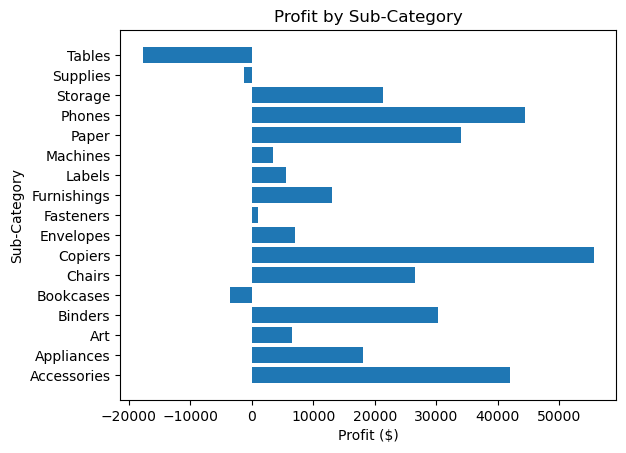

In [8]:
# Plot an horizontal bar graph showing profit by sub-category
plt.barh(
    subcategory_performance["Sub-Category"],
    subcategory_performance["Profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")

plt.show()

##### Individual Product Performance

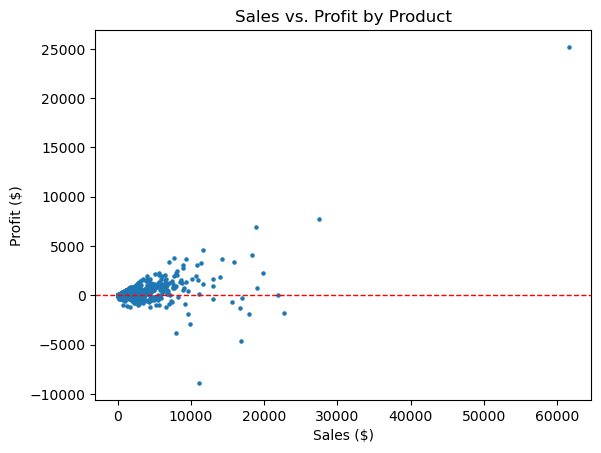

In [9]:
product_performance = (
    data.groupby("Product Name")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Scatter plot showing every product with its sales and profit
plt.scatter(
    product_performance["Sales"],
    product_performance["Profit"],
    s = 5
)

plt.title("Sales vs. Profit by Product")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.show()

In [10]:
# Define top 25% of products by sales 
sales_threshold = product_performance["Sales"].quantile(0.75)
# Define top 25% of products by profit
profit_threshold = product_performance["Profit"].quantile(0.75)
# Identify products with high sales but negative profit
high_sales_loss_products = product_performance[
    (product_performance["Sales"] >= sales_threshold)
    & (product_performance["Profit"] < 0)
].sort_values("Profit")

high_sales_loss_products.head()

,Product Name,Sales,Profit
475,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
985,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
476,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156
376,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976


In [11]:
# Identify products with both high sales and high profit
high_sales_profit_products = product_performance[
    (product_performance["Sales"] >= sales_threshold)
    & (product_performance["Profit"] >= profit_threshold)
].sort_values("Profit", ascending = False)

high_sales_profit_products.head()

,Product Name,Sales,Profit
404,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
400,Canon PC1060 Personal Laser Copier,11619.834,4570.9347
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766


#### **Key Findings**
- `Technology` is the strongest-performing product category, generating the highest sales (`$836,154`), profit (`$145,454`), and profit margin (`17.40%`). This indicates that `Technology` is a major contributor to both revenue and profitability.
- `Furniture` represents a profitability concern. Although it ranks second in sales, it has the lowest profit margin among the three categories at just `2.50%`, suggesting that strong sales do not necessarily translate into strong profitability.
- `Copiers`, `Phones`, and `Accessories` are the sub-categories that generate the highest total profit. However, the highest profit margins come from Labels (`44.42%`), Paper (`43.39%`), and Envelopes (`42.27%`). This shows that the sub-categories generating the most total profit are not necessarily those with the highest profit margins.
- Three sub-categories generate negative profit: `Supplies`, `Bookcases`, and `Tables`. Tables have the lowest profit margin at `-8.56%`, indicating that sales in this sub-category are resulting in an overall loss.
- Sales and profit do not always move together at the product level. Some products generate relatively high sales while producing negative profit. The `Cubify CubeX 3D Printer Double Head Print` generated the largest loss, at `-$8,879`.
- A smaller group of products combines relatively high sales with high profit, making them strong contributors to both sales and profitability. The `Canon imageCLASS 2200 Advanced Copier` generated the highest individual product profit at `$25,200`.


### **3. Customer Analysis**

**Business Question:** Which customer segments generate the most value? Are customers with high sales also the most profitable?

##### Customer Segment Performance

In [12]:
segment_performance = (
    data.groupby("Segment")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Calculate and add profit margin to each customer segment
segment_performance["Profit Margin"] = (
    segment_performance["Profit"] / segment_performance["Sales"] * 100
)

segment_performance

,Segment,Sales,Profit,Profit Margin
0,Consumer,1.161401e+06,134119.2092,11.548050
1,Corporate,7.061464e+05,91979.1340,13.025506
2,Home Office,4.296531e+05,60298.6785,14.034269


##### Individual Customer Performance

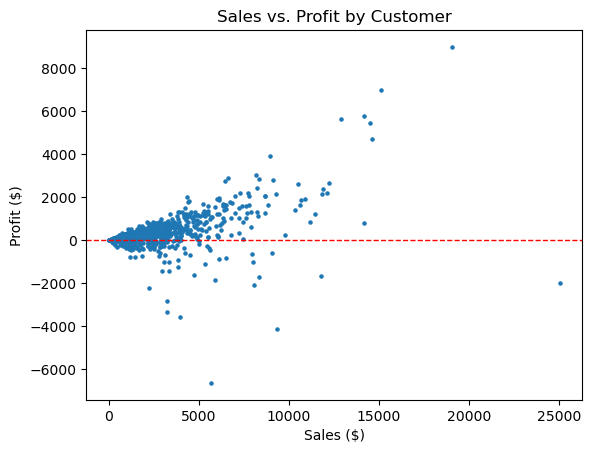

In [13]:
customer_performance = (
    data.groupby("Customer Name")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Scatter plot showing every customer with their sales and profit
plt.scatter(
    customer_performance["Sales"],
    customer_performance["Profit"],
    s = 5
)

plt.title("Sales vs. Profit by Customer")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()

In [14]:
# Define top 25% of customers by sales 
sales_customer_threshold = customer_performance["Sales"].quantile(0.75)
# Define top 25% of customers by profit
profit_customer_threshold = customer_performance["Profit"].quantile(0.75)
# Identify customers generating high sales but negative profit
high_sales_loss_customers = customer_performance[
    (customer_performance["Sales"] >= sales_customer_threshold)
    & (customer_performance["Profit"] < 0)
].sort_values("Sales", ascending = False)

high_sales_loss_customers.head()

,Customer Name,Sales,Profit
686,Sean Miller,25043.050,-1980.7393
75,Becky Martin,11789.630,-1659.9581
307,Grant Thornton,9351.212,-4108.6589
606,Peter Fuller,9062.864,-614.2943
557,Natalie Fritzler,8322.826,-1695.9714


In [15]:
# Identify customers with high sales and high profit
high_sales_profit_customers = customer_performance[
    (customer_performance["Sales"] >= sales_customer_threshold)
    & (customer_performance["Profit"] >= profit_customer_threshold)
].sort_values("Profit", ascending = False)

high_sales_profit_customers.head()

,Customer Name,Sales,Profit
730,Tamara Chand,19052.218,8981.3239
622,Raymond Buch,15117.339,6976.0959
671,Sanjit Chand,14142.334,5757.4119
334,Hunter Lopez,12873.298,5622.4292
6,Adrian Barton,14473.571,5444.8055


#### **Key Findings** 

- The `Consumer` segment generates the highest sales and total profit, with `$1,161,401` in sales and `$134,119` in profit. Its profit margin is `11.54%`, and this segment alone accounts for approximately half of total sales.
- The `Home Office` segment has the highest profit margin, generating approximately `$14.03` in profit for every `$100` in sales. This indicates that, while it generates less total sales than the Consumer segment, it converts a larger share of its sales into profit.
- High customer sales do not always translate into high profitability. Several customers generate high sales but produce little or negative profit. For example, Sean Miller generated `$25,043` in sales but resulted in a `$1,980` loss.
- Some customers contribute strongly to both sales and profitability. For example, Tamara Chand generated `$19,052` in sales and `$8,981` in profit, the highest profit among individual customers.

### **4. Regional Analysis**

**Business Question:** How does profitability vary across regions and states? Where do high sales fail to translate into profit?

##### Region Performance

In [16]:
regional_performance = (
    data.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Calculate and add profit margin to each region
regional_performance["Profit Margin"] = (
    regional_performance["Profit"] / regional_performance["Sales"] * 100
)

regional_performance

,Region,Sales,Profit,Profit Margin
0,Central,501239.8908,39706.3625,7.921629
1,East,678781.2400,91522.7800,13.483399
2,South,391721.9050,46749.4303,11.934342
3,West,725457.8245,108418.4489,14.944831


##### State Performance


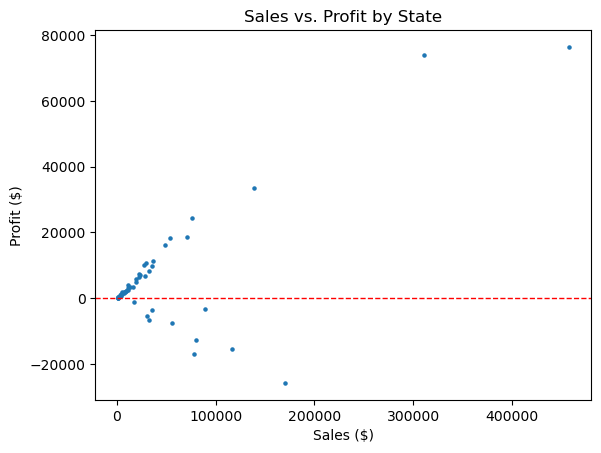

In [17]:
state_performance = (
    data.groupby("State")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)
state_performance["Profit Margin"] = (
    state_performance["Profit"] / state_performance["Sales"] * 100
)

plt.scatter(
    state_performance["Sales"],
    state_performance["Profit"],
    s = 5
)

plt.title("Sales vs. Profit by State")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.show()

In [18]:
# Define top 25% of states by sales 
state_sales_threshold = state_performance["Sales"].quantile(0.75)
# Define top 25% of states by profit
state_profit_threshold = state_performance["Profit"].quantile(0.75)
# Identify states generating high sales but negative profit
high_sales_loss_states = state_performance[
    (state_performance["Sales"] >= state_sales_threshold)
    & (state_performance["Profit"] < 0)
].sort_values("Sales", ascending = False)

high_sales_loss_states

,State,Sales,Profit,Profit Margin
41,Texas,170188.0458,-25729.3563,-15.118192
36,Pennsylvania,116511.9140,-15559.9603,-13.354823
8,Florida,89473.7080,-3399.3017,-3.799219
11,Illinois,80166.1010,-12607.8870,-15.727205
33,Ohio,78258.1360,-16971.3766,-21.686405
31,North Carolina,55603.1640,-7490.9122,-13.472097


In [19]:
# Identify states with high sales and high profit
high_sales_profit_states = state_performance[
    (state_performance["Sales"] >= state_sales_threshold)
    & (state_performance["Profit"] >= state_profit_threshold)
].sort_values("Profit", ascending = False)

high_sales_profit_states

,State,Sales,Profit,Profit Margin
3,California,457687.6315,76381.3871,16.688541
30,New York,310876.2710,74038.5486,23.816082
45,Washington,138641.2700,33402.6517,24.092863
20,Michigan,76269.6140,24463.1876,32.074618
44,Virginia,70636.7200,18597.9504,26.329012
12,Indiana,53555.3600,18382.9363,34.325110
9,Georgia,49095.8400,16250.0433,33.098615


#### **Key Findings**
- The `West` region generates the highest sales, profit, and profit margin, with `$725,457` in sales, `$108,418` in profit, and a `14.94%` profit margin.
- The `Central` region has the lowest profit margin, despite generating more sales than the South region. This highlights that higher sales do not necessarily translate into higher profitability.
- At the state level, most states generate positive profit; however, several states with high sales have negative profit margins. `Texas`, `Pennsylvania`, `Illinois`, `North Carolina`, and `Ohio` all have profit margins below -10%, with Ohio having the lowest margin at `-21.68%`.
- `California` and `New York` generate the highest sales and profit among the states, with profit margins of `16.69%` and `23.82%`, respectively.
- `Indiana` stands out for its high profitability, with a `34.33%` profit margin, the highest among the high-sales states analyzed.

### **5. Discount and Profitability**

**Business Question:** How does discounting affect sales and profitability? At what discount levels does profitability decline?

In [20]:
discount_performance = (
    data.groupby("Discount")[["Sales", "Profit"]]
    .sum()
    .reset_index()
)

# Calculate and add profit margin to each discount level
discount_performance["Profit Margin"] = (
    discount_performance["Profit"] / discount_performance["Sales"] * 100
)

discount_performance

,Discount,Sales,Profit,Profit Margin
0,0.00,1.087908e+06,320987.6032,29.505019
1,0.10,5.436935e+04,9029.1770,16.607108
2,0.15,2.755852e+04,1418.9915,5.149012
3,0.20,7.645944e+05,90337.3060,11.815063
4,0.30,1.032267e+05,-10369.2774,-10.045155
5,0.32,1.449346e+04,-2391.1377,-16.498047
6,0.40,1.164178e+05,-23057.0504,-19.805437
7,0.45,5.484974e+03,-2493.1111,-45.453472
8,0.50,5.891854e+04,-20506.4281,-34.804712
9,0.60,6.644700e+03,-5944.6552,-89.464614


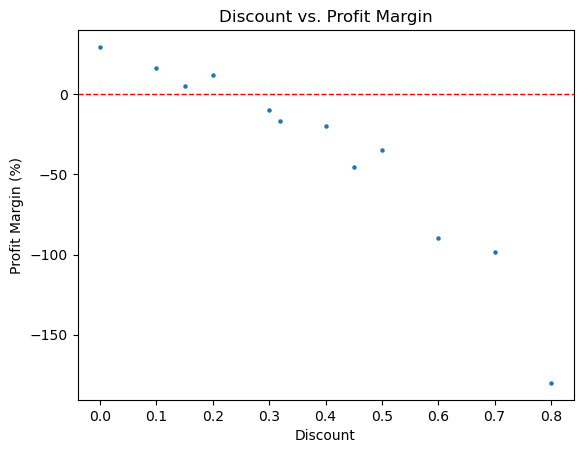

In [22]:
plt.scatter(
    discount_performance["Discount"],
    discount_performance["Profit Margin"],
    s = 5
)

plt.title("Discount vs. Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.show()

In [24]:
# Identify the transactions with high discount levels
high_discount_performance = data[data["Discount"] >= 0.30]
# Calculate total sales and profit of high-discount transactions
high_discount_sales = high_discount_performance["Sales"].sum()
high_discount_profit = high_discount_performance["Profit"].sum()
# Calculate total profit margin of high-discount transactions
high_discount_margin = (
    high_discount_profit / high_discount_sales * 100
)
print(f"Sales: ${high_discount_sales:,.2f}")
print(f"Profit: ${high_discount_profit:,.2f}")
print(f"Profit Margin: {high_discount_margin:.2f}%")

Sales: $362,770.15
Profit: $-135,376.06
Profit Margin: -37.32%


#### **Key Findings**

- Higher discount levels are associated with lower profit and profit margins. Transactions with discounts of `30% or more` resulted in negative profit margins.
- A `80%` discount had the lowest profit margin at `-180.03%`, followed by a `70%` discount at `-98.66%`. This indicates that these high discount levels resulted in significant losses relative to the sales revenue generated.
- Transactions with discounts of 30% or more generated `$362,770.15` in sales but resulted in a total loss of `$135,376.06`. This represents a negative profit margin of `37.32%`, meaning the business lost approximately `$37.32` for every `$100` in sales.
- High discount levels can generate substantial sales revenue while still reducing profitability.

### **Business Implications**
- The Superstore shows overall growth in both sales and profit over the period analyzed. However, the overall profit margin of 12.47% suggests that sales growth should be evaluated alongside profitability to ensure that increases in sales continue to generate substantial profit.
- Product and customer performance should not be evaluated based on sales volume alone, but on both sales and profitability. The differences across categories, sub-categories, individual products, and customers show that strong sales do not always translate into strong profits.
- The differences in profitability and profit margins between regions and states show that geographic markets can contribute differently to overall business performance.
- Higher discount levels are associated with lower profitability, meaning discounting can reduce the financial return generated from sales.


### **Business Recommendations**
- Prioritize further investigation of product and sub-category profitability, particularly areas generating negative or low margins. Products such as `Tables`, `Bookcases`, and `Supplies` should be examined to identify factors contributing to their losses. The Superstore could consider adjusting discount levels for these products where high discounting is identified as a contributing factor, while continuing to evaluate their sales and profitability.
- Prioritize customer profitability when evaluating high-value customers and segments. Ccustomers contributing strongly to both sales and profit should be examined to understand characteristics associated with profitable customers.
- Investigate regions and states where strong sales are not translating into profitability. Areas such as the `Central region` and states such as `Texas` should be examined to identify factors contributing to their lower profitability. The Superstore could then consider region-specific strategies based on the factors identified, rather than focusing only on increasing sales.
- The Superstore could evaluate whether high discount levels are concentrated among particular products, regions, or customer groups to consider adjustments to its discount strategy.